In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier


In [4]:
df=pd.read_csv('final.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes_category
0,Female,80.0,0,1,never,25.19,6.6,140,2
1,Female,54.0,0,0,No Info,27.32,6.6,80,2
2,Male,28.0,0,0,never,27.32,5.7,158,1
3,Female,36.0,0,0,current,23.45,5.0,155,2
4,Male,76.0,1,1,current,20.14,4.8,155,2


In [5]:
df.duplicated().sum()

np.int64(3120)

In [6]:
df = df.drop_duplicates()

In [7]:
x=df.drop('diabetes_category',axis=1)
y=df['diabetes_category']

In [8]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes_category
0,Female,80.0,0,1,never,25.19,6.6,140,2
1,Female,54.0,0,0,No Info,27.32,6.6,80,2
2,Male,28.0,0,0,never,27.32,5.7,158,1
3,Female,36.0,0,0,current,23.45,5.0,155,2
4,Male,76.0,1,1,current,20.14,4.8,155,2


In [9]:
df = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96880 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          96880 non-null  float64
 1   hypertension                 96880 non-null  int64  
 2   heart_disease                96880 non-null  int64  
 3   bmi                          96880 non-null  float64
 4   HbA1c_level                  96880 non-null  float64
 5   blood_glucose_level          96880 non-null  int64  
 6   diabetes_category            96880 non-null  int64  
 7   gender_Male                  96880 non-null  bool   
 8   gender_Other                 96880 non-null  bool   
 9   smoking_history_current      96880 non-null  bool   
 10  smoking_history_ever         96880 non-null  bool   
 11  smoking_history_former       96880 non-null  bool   
 12  smoking_history_never        96880 non-null  bool   
 13  smoking_history_not c

In [11]:
x=df.drop('diabetes_category',axis=1)
y=df['diabetes_category']

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
smote = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [14]:
model = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10)
model.fit(X_train_resampled, y_train_resampled)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [15]:
model.score(x_test, y_test)*100, model.score(X_train_resampled, y_train_resampled)*100

(85.79686209744013, 82.79447873766178)

In [16]:
x.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'gender_Male', 'gender_Other',
       'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')

In [17]:
y_pred = model.predict(x_test)
y_pred

array([2, 1, 2, ..., 2, 2, 1])

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.51      0.65      3151
           1       0.79      0.83      0.81      7138
           2       0.90      1.00      0.95      9087

    accuracy                           0.86     19376
   macro avg       0.87      0.78      0.80     19376
weighted avg       0.86      0.86      0.85     19376



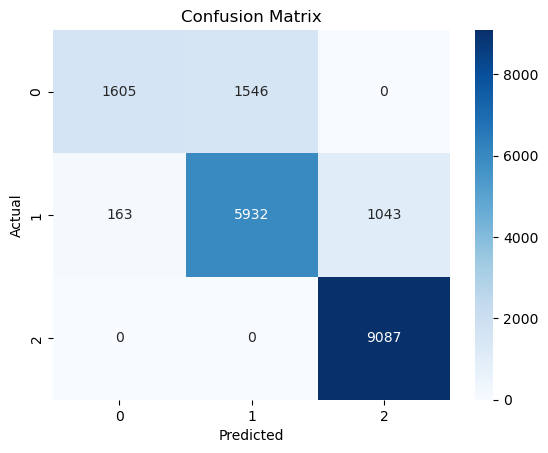

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

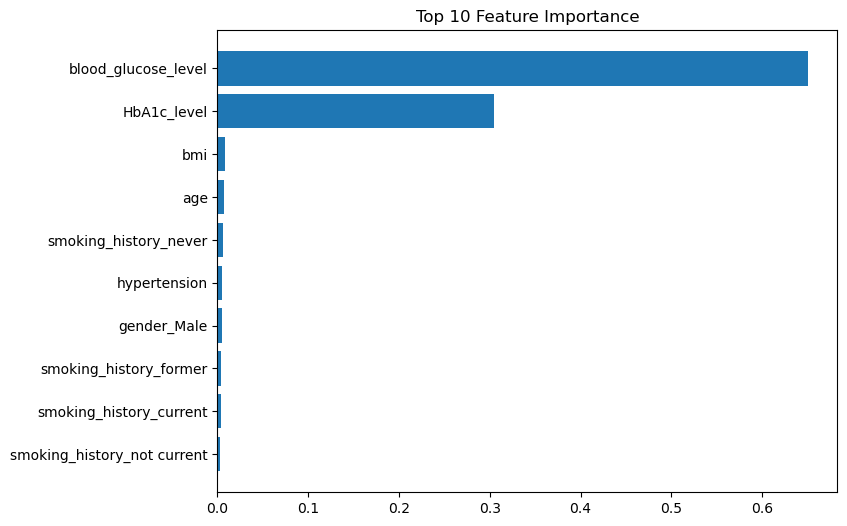

In [20]:
import numpy as np

importances = model.feature_importances_
feature_names = x.columns

sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.barh(feature_names[sorted_idx][:10],
         importances[sorted_idx][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

In [21]:
import joblib

In [22]:
joblib.dump(model, 'diabetes_model.pkl')

['diabetes_model.pkl']